# Phase 8 : Clustering

**Objective**

Discover naturally occurring lifestyle groups within the population using K-Means clustering and determine whether clustering performance improves when PCA-transformed features are used instead of the original standardized feature set.

**Hypothesis:**

* The original standardized 12-feature dataset will produce clustering quality that is equal to or slightly better than the 3-PC representation.
* Even if the metrics are very close, the original feature space will win because the resulting clusters can be explained in terms of meaningful lifestyle factors such as mental wellness, productivity, social wellness, and stress burden instead of abstract principal components.

<img src="./images/clustering_roadmap.png" width="500">

**Inputs**
* scaled_features.csv
* pca_features.csv

**Outputs**
* Optimal number of clusters
* Cluster assignments
* Cluster evaluation metrics
* Comparison report
* Final clustering dataset

**Expected Deliverables**

By the end of this notebook, we should answer:

* What is the optimal number of clusters?<br>
* Does PCA improve clustering?<br>
* Which representation should be used?<br>
* What are the characteristics of each cluster?

In [6]:
# Load datasets

import pandas as pd
import numpy as np

scaled_df = pd.read_csv("dataset//scaled_features.csv")
pca_df = pd.read_csv("dataset//pca_features.csv")

print("Scaled Dataset Shape :", scaled_df.shape)
print("PCA Dataset Shape    :", pca_df.shape)

Scaled Dataset Shape : (15489, 12)
PCA Dataset Shape    : (15489, 3)


# Elbow Method

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

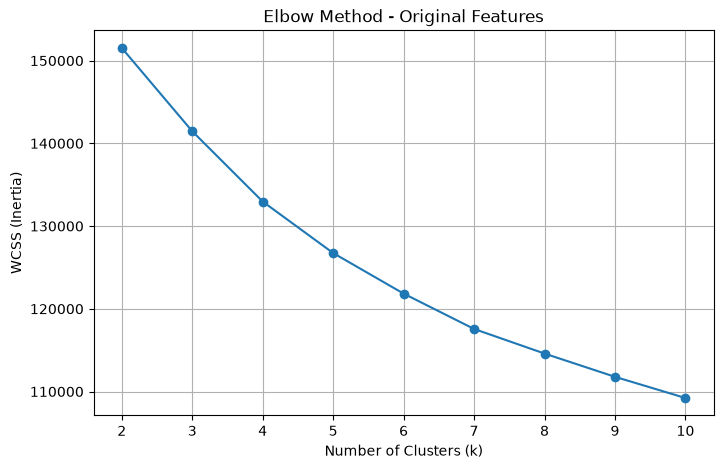

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method - Original Features")

plt.grid(True)

plt.show()

# Silhouette Analysis

| Score     | Meaning    |
| --------- | ---------- |
| >0.70     | Excellent  |
| 0.50–0.70 | Good       |
| 0.25–0.50 | Reasonable |
| <0.25     | Weak       |


# Comprehensive Cluster Evaluation

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

k_values = range(2, 11)

results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(scaled_df)

    results.append({

        "k": k,

        "WCSS": kmeans.inertia_,

        "Silhouette Score":
            silhouette_score(scaled_df, labels),

        "Davies-Bouldin Index":
            davies_bouldin_score(scaled_df, labels),

        "Calinski-Harabasz Index":
            calinski_harabasz_score(scaled_df, labels)

    })

evaluation_df = pd.DataFrame(results)

display(evaluation_df.round(4))

,k,WCSS,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,151526.5160,0.1606,2.0634,3509.9391
1,3,141460.6258,0.1068,2.4647,2430.7004
2,4,132962.6739,0.1021,2.3179,2053.8103
3,5,126739.0902,0.1042,2.2314,1805.9825
4,6,121837.5971,0.0953,2.2362,1627.3857
5,7,117564.2571,0.0965,2.2323,1499.1560
6,8,114590.2854,0.0914,2.3101,1375.6503
7,9,111777.8414,0.0910,2.2941,1282.5869
8,10,109217.9635,0.0937,2.1946,1207.0332


# Clustering Evaluation

**Ranking the Metrics**

* Silhouette → Higher is better
* Davies-Bouldin → Lower is better
* Calinski-Harabasz → Higher is better

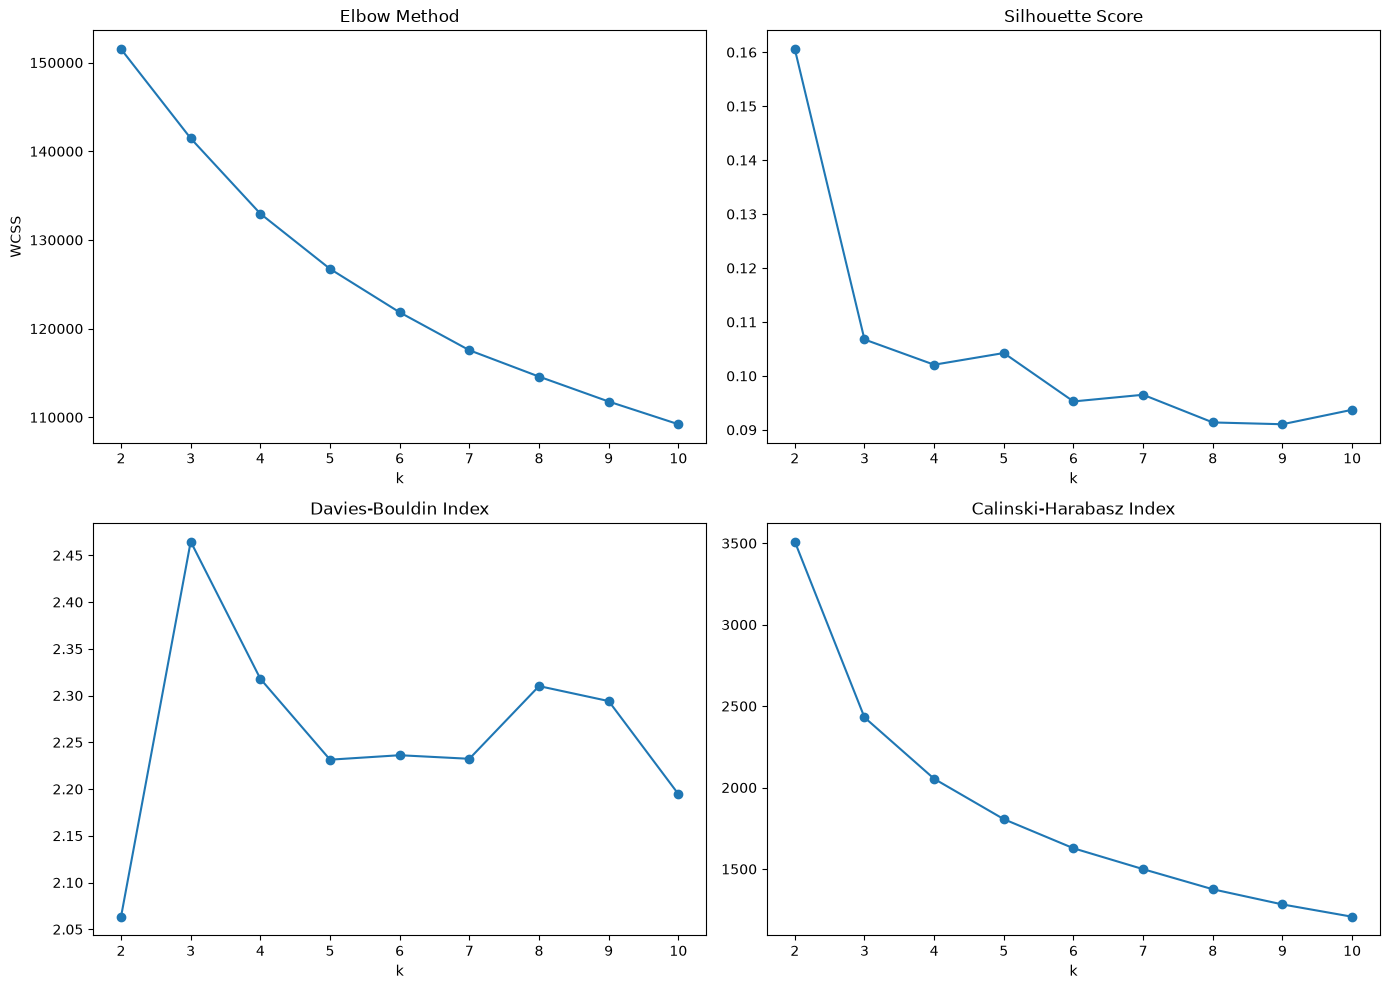

In [10]:


fig, axes = plt.subplots(2, 2, figsize=(14,10))

# WCSS
axes[0,0].plot(
    evaluation_df["k"],
    evaluation_df["WCSS"],
    marker="o"
)
axes[0,0].set_title("Elbow Method")
axes[0,0].set_xlabel("k")
axes[0,0].set_ylabel("WCSS")

# Silhouette
axes[0,1].plot(
    evaluation_df["k"],
    evaluation_df["Silhouette Score"],
    marker="o",
)
axes[0,1].set_title("Silhouette Score")
axes[0,1].set_xlabel("k")

# Davies
axes[1,0].plot(
    evaluation_df["k"],
    evaluation_df["Davies-Bouldin Index"],
    marker="o",
)
axes[1,0].set_title("Davies-Bouldin Index")
axes[1,0].set_xlabel("k")

# Calinski
axes[1,1].plot(
    evaluation_df["k"],
    evaluation_df["Calinski-Harabasz Index"],
    marker="o",
)
axes[1,1].set_title("Calinski-Harabasz Index")
axes[1,1].set_xlabel("k")

plt.tight_layout()

plt.show()

In [11]:
# ==========================================================
# Rank Each Metric
# ==========================================================

ranking_df = evaluation_df.copy()

ranking_df["Silhouette Rank"] = (
    ranking_df["Silhouette Score"]
    .rank(ascending=False)
)

ranking_df["Davies Rank"] = (
    ranking_df["Davies-Bouldin Index"]
    .rank(ascending=True)
)

ranking_df["CH Rank"] = (
    ranking_df["Calinski-Harabasz Index"]
    .rank(ascending=False)
)

ranking_df["Overall Rank"] = (

    ranking_df["Silhouette Rank"] +

    ranking_df["Davies Rank"] +

    ranking_df["CH Rank"]

)

ranking_df = ranking_df.sort_values("Overall Rank")

display(ranking_df.round(3))

,k,WCSS,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Silhouette Rank,Davies Rank,CH Rank,Overall Rank
0,2,151526.516,0.161,2.063,3509.939,1.0,1.0,1.0,3.0
3,5,126739.090,0.104,2.231,1805.982,3.0,3.0,4.0,10.0
1,3,141460.626,0.107,2.465,2430.700,2.0,9.0,2.0,13.0
2,4,132962.674,0.102,2.318,2053.810,4.0,8.0,3.0,15.0
5,7,117564.257,0.097,2.232,1499.156,5.0,4.0,6.0,15.0
4,6,121837.597,0.095,2.236,1627.386,6.0,5.0,5.0,16.0
8,10,109217.964,0.094,2.195,1207.033,7.0,2.0,9.0,18.0
6,8,114590.285,0.091,2.310,1375.650,8.0,7.0,7.0,22.0
7,9,111777.841,0.091,2.294,1282.587,9.0,6.0,8.0,23.0


After a thorough evaluation now we can conclude that we can train our model for k=2, k=5

In [12]:
# Fit Final KMeans Model (k = 2)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(scaled_df)

In [13]:
# Create Cluster Dataset

cluster_df = scaled_df.copy()

cluster_df["Cluster"] = cluster_labels

cluster_df.shape

(15489, 13)

In [14]:
# Cluster Size

cluster_counts = (

    cluster_df["Cluster"]
    .value_counts()
    .sort_index()

)

print(cluster_counts)

Cluster
0    7683
1    7806
Name: count, dtype: int64


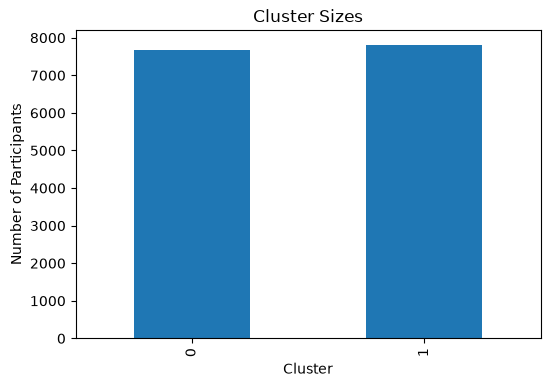

In [15]:
import matplotlib.pyplot as plt

cluster_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Participants")
plt.show()

In [16]:
# Cluster Centers

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=scaled_df.columns
)

display(
    centroids.round(3)
)

,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
0,-0.451,-0.405,0.077,-0.295,-0.457,-0.183,-0.537,-0.500,-0.432,-0.560,-0.532,0.479
1,0.444,0.398,-0.076,0.290,0.449,0.180,0.528,0.492,0.425,0.551,0.523,-0.471


In [ ]:
# Add Cluster Labels to Original Feature Space

model_df = pd.read_csv("dataset//model_dataset.csv")
profile_df = model_df.copy()

profile_df["Cluster"] = cluster_labels

cluster_profile = (
    profile_df
    .groupby("Cluster")
    .mean()
)

display(cluster_profile.round(2))

,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
Cluster,,,,,,,,,,,,
0,3.73,1.97,1.45,1.60,4.3,1.43,0.28,0.47,0.52,0.37,0.50,0.50
1,6.70,3.45,1.37,1.86,7.1,1.78,0.48,0.70,0.67,0.61,0.68,0.32


,PLACES_VISITED,DONATION,BMI_RANGE,SUFFICIENT_INCOME,PERSONAL_AWARDS,AGE,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
Cluster,,,,,,,,,,,,
0,0.858094,0.420087,0.290761,0.328760,1.0,0.287624,0.000000,0.049061,0.060388,0.02203,0.055548,0.055938
1,0.941238,0.462451,0.155356,0.227273,1.0,0.215309,0.023634,0.056092,0.051154,0.04264,0.054001,0.000000


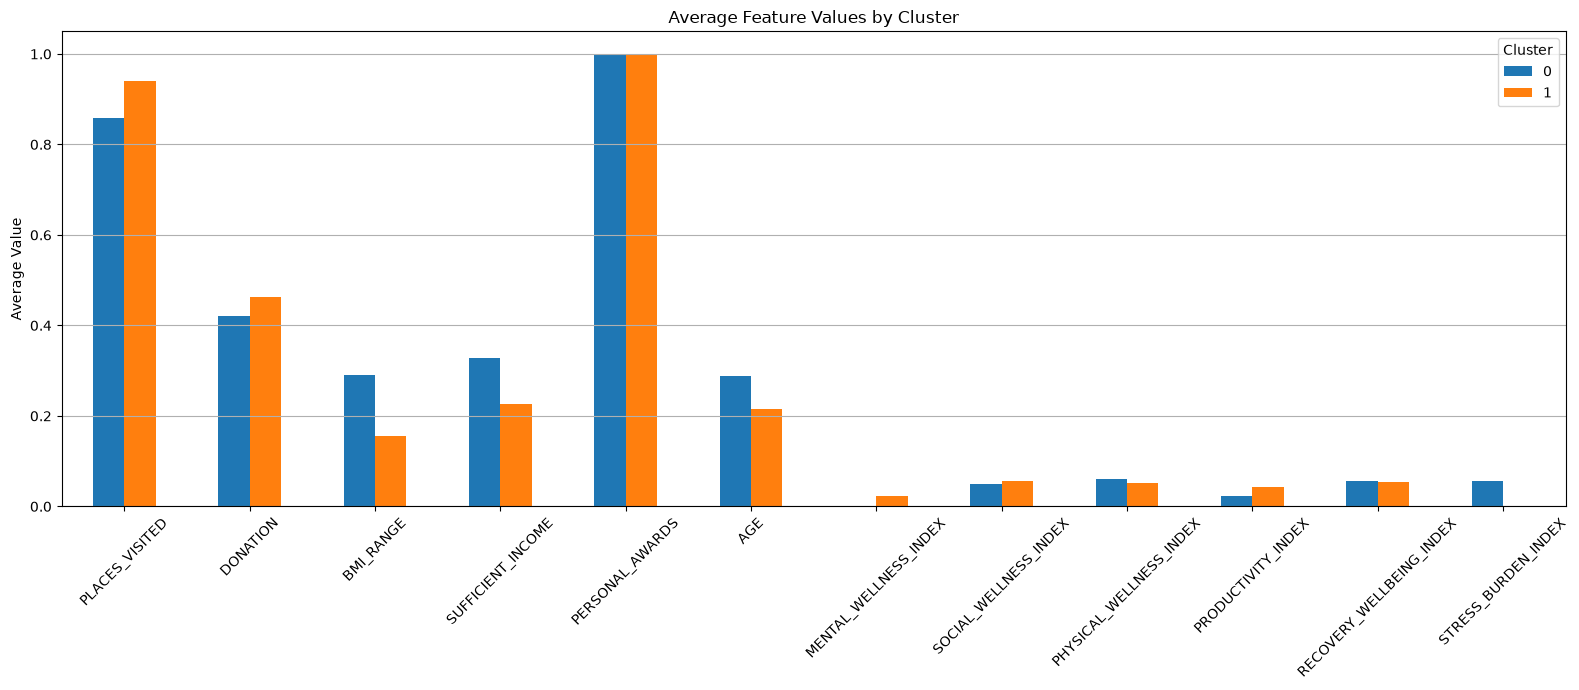

In [24]:
# ======================================================
# Cluster Profile Comparison
# ======================================================

from sklearn.preprocessing import MinMaxScaler

# Normalize Cluster Profiles ONLY for Visualization


visual_scaler = MinMaxScaler()

cluster_profile_normalized = pd.DataFrame(
    visual_scaler.fit_transform(cluster_profile.T).T,
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

display(cluster_profile_normalized)

cluster_profile_normalized.T.plot(

    kind="bar",

    figsize=(16,7)

)

plt.title("Average Feature Values by Cluster")

plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.legend(title="Cluster")

plt.tight_layout()

plt.show()

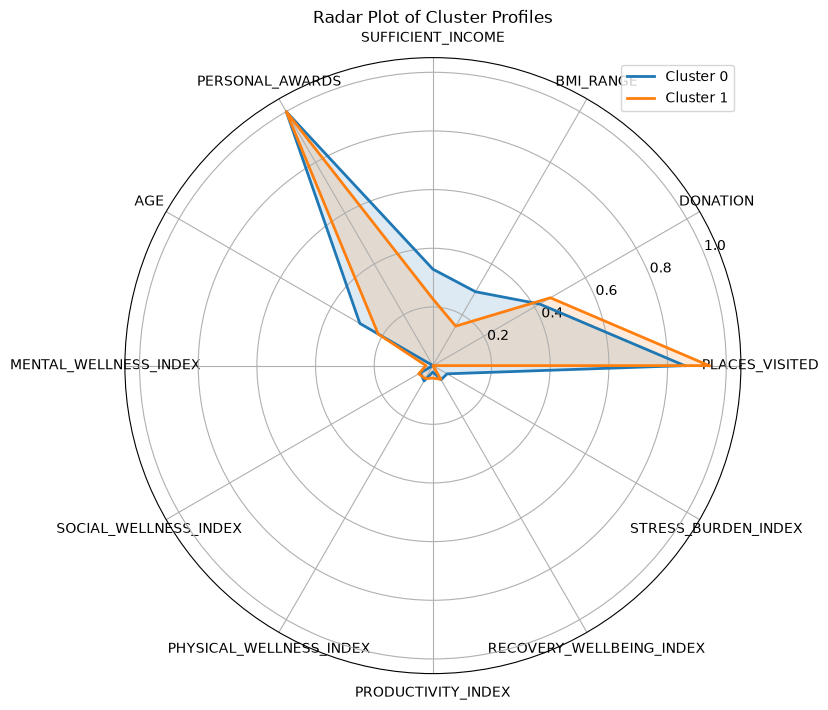

In [26]:
import numpy as np
import matplotlib.pyplot as plt

labels = cluster_profile_normalized.columns.tolist()

num_vars = len(labels)

angles = np.linspace(
    0,
    2*np.pi,
    num_vars,
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

for idx in cluster_profile_normalized.index:

    values = cluster_profile_normalized.loc[idx].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {idx}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(labels)

plt.title("Radar Plot of Cluster Profiles")

plt.legend()

plt.show()